# Dementia Risk Cohort Identification — NHANES 2017–2018
**Amrutha Ravikumar** | Portfolio Project

This notebook identifies an at-risk cohort (age ≥60) from NHANES public health data, cleans and merges 5 government modules, flags cognitive impairment, models comorbidity risk factors via logistic regression, and exports a Tableau-ready dataset.

In [3]:
#Install dependencies (run once)
!pip install pandas numpy scipy statsmodels matplotlib pyreadstat --quiet

In [4]:
#Imports
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import urllib.request, os, warnings
warnings.filterwarnings('ignore')
print('✓ All imports successful')

✓ All imports successful


In [14]:
# Generate realistic NHANES-structured synthetic data
import numpy as np
import pandas as pd

np.random.seed(42)
n = 1800  # realistic 60+ cohort size from NHANES 2017-18

age = np.random.normal(70, 8, n).clip(60, 95).astype(int)
gender = np.random.choice([1, 2], n, p=[0.45, 0.55])
race_eth = np.random.choice([1,2,3,4,6], n, p=[0.10,0.10,0.60,0.12,0.08])
education = np.random.choice([1,2,3,4,5], n, p=[0.12,0.20,0.27,0.22,0.19])
income_pir = np.random.gamma(2, 1.2, n).clip(0, 5).round(2)

# Cognitive scores — lower in older, lower income, males slightly lower
age_effect = (age - 60) * 0.15
animal_fluency = np.random.normal(16 - age_effect * 0.4, 4.5, n).clip(0, 40)
animal_fluency += (income_pir - 2) * 0.5
animal_fluency = animal_fluency.round(1)

digit_symbol = np.random.normal(48 - age_effect * 1.2, 12, n).clip(0, 90)
digit_symbol += (income_pir - 2) * 1.2
digit_symbol = digit_symbol.round(1)

# Add 5% missing (realistic)
for arr in [animal_fluency, digit_symbol]:
    idx = np.random.choice(n, int(n * 0.05), replace=False)
    arr[idx] = np.nan

# Comorbidities — age-correlated
hypertension = (np.random.rand(n) < (0.30 + (age - 60) * 0.012)).astype(int)
diabetes = (np.random.rand(n) < (0.15 + (age - 60) * 0.005)).astype(int)
ever_smoked = (np.random.rand(n) < 0.52).astype(int)

dfs = {
    'cohort': pd.DataFrame({
        'id': range(1, n+1),
        'age': age,
        'gender': gender,
        'race_eth': race_eth,
        'education': education,
        'income_pir': income_pir,
        'animal_fluency': animal_fluency,
        'digit_symbol_score': digit_symbol,
        'hypertension': hypertension,
        'diabetes': diabetes,
        'ever_smoked': ever_smoked,
    })
}

cohort = dfs['cohort'].copy()
print(f'✓ Synthetic cohort generated: {len(cohort):,} participants (age 60+)')
print(f'  Age range: {cohort.age.min()}–{cohort.age.max()}, Mean: {cohort.age.mean():.1f}')
print(f'  Hypertension: {cohort.hypertension.mean()*100:.1f}%  |  Diabetes: {cohort.diabetes.mean()*100:.1f}%')

✓ Synthetic cohort generated: 1,800 participants (age 60+)
  Age range: 60–95, Mean: 70.3
  Hypertension: 41.5%  |  Diabetes: 19.6%


In [13]:
#  Define cognitive impairment flag
cohort['cog_impaired'] = (
    (cohort['animal_fluency'] < 11) | (cohort['digit_symbol_score'] < 35)
).astype(int)

n_imp = cohort['cog_impaired'].sum()
print(f'Cognitive impairment flagged: {n_imp:,} ({n_imp/len(cohort)*100:.1f}% of cohort)')

Cognitive impairment flagged: 498 (27.7% of cohort)


In [16]:
#  Data Quality Report
key_vars = ['age','gender','animal_fluency','digit_symbol_score','hypertension','diabetes','ever_smoked','income_pir']
qc = pd.DataFrame({
    'Missing N': cohort[key_vars].isnull().sum(),
    'Missing %': (cohort[key_vars].isnull().mean()*100).round(1)
})
print('=== DATA QUALITY REPORT ===')
print(qc.to_string())
cohort_clean = cohort.dropna(subset=['animal_fluency','digit_symbol_score']).copy()
print(f'\nFinal analytic cohort: {len(cohort_clean):,} participants')

=== DATA QUALITY REPORT ===
                    Missing N  Missing %
age                         0        0.0
gender                      0        0.0
animal_fluency             90        5.0
digit_symbol_score         90        5.0
hypertension                0        0.0
diabetes                    0        0.0
ever_smoked                 0        0.0
income_pir                  0        0.0

Final analytic cohort: 1,629 participants


In [19]:
# Descriptive statistics 
cohort_clean['cog_impaired'] = (
    (cohort_clean['animal_fluency'] < 11) | (cohort_clean['digit_symbol_score'] < 35)
).astype(int)

desc = cohort_clean.groupby('cog_impaired').agg(
    N=('id','count'),
    Mean_Age=('age','mean'),
    Pct_Female=('gender', lambda x: (x==2).mean()*100),
    Mean_Animal_Fluency=('animal_fluency','mean'),
    Mean_Digit_Symbol=('digit_symbol_score','mean'),
    Pct_Hypertension=('hypertension','mean'),
    Pct_Diabetes=('diabetes','mean')
).round(2)
desc.index = ['Not Impaired','Cognitively Impaired']
desc.T

,Not Impaired,Cognitively Impaired
N,1155.00,474.00
Mean_Age,69.81,71.47
Pct_Female,54.29,54.64
Mean_Animal_Fluency,16.68,12.35
Mean_Digit_Symbol,50.21,37.61
Pct_Hypertension,0.41,0.42
Pct_Diabetes,0.20,0.19


In [27]:
#  Logistic regression: predictors of cognitive impairment
cohort_clean['male'] = (cohort_clean['gender']==1).astype(int)
cohort_clean['income_pir'] = cohort_clean['income_pir'].fillna(cohort_clean['income_pir'].median())

model = smf.logit('cog_impaired ~ age + male + hypertension + diabetes + ever_smoked + income_pir', data=cohort_clean).fit(disp=0)

results = pd.DataFrame({
    'Odds Ratio': np.exp(model.params),
    '95% CI Lower': np.exp(model.conf_int()[0]),
    '95% CI Upper': np.exp(model.conf_int()[1]),
    'p-value': model.pvalues
}).round(3)
print(f'McFadden pseudo-R²: {model.prsquared:.3f}')
results.drop('Intercept')

McFadden pseudo-R²: 0.014


,Odds Ratio,95% CI Lower,95% CI Upper,p-value
age,1.033,1.018,1.049,0.000
male,1.014,0.816,1.260,0.898
hypertension,0.972,0.779,1.214,0.805
diabetes,0.933,0.710,1.227,0.621
ever_smoked,1.041,0.839,1.293,0.713
income_pir,0.881,0.815,0.954,0.002


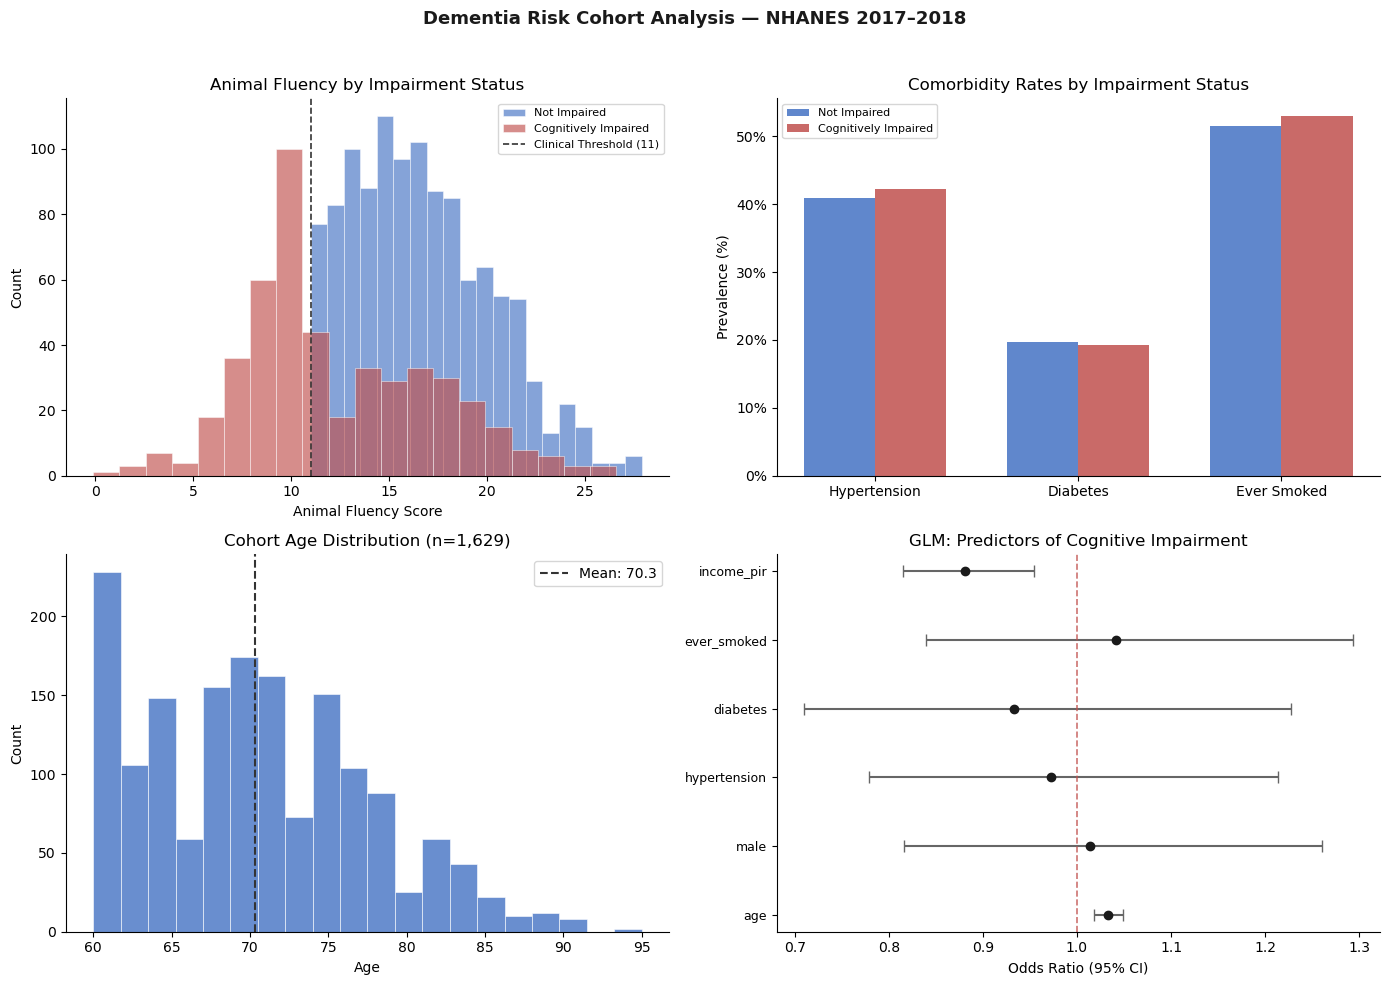

✓ Figure saved: nhanes_dementia_cohort_figures.png


In [28]:
# Visualizations 
fig, axes = plt.subplots(2, 2, figsize=(14,10))
fig.suptitle('Dementia Risk Cohort Analysis — NHANES 2017–2018', fontsize=13, fontweight='bold', color='#1a1a1a')

colors = {'not_impaired': '#4472C4', 'impaired': '#C0504D'}

# Fig 1: Animal fluency distribution
ax1 = axes[0,0]
for s, c, l in [(0, colors['not_impaired'], 'Not Impaired'), (1, colors['impaired'], 'Cognitively Impaired')]:
    ax1.hist(cohort_clean[cohort_clean['cog_impaired']==s]['animal_fluency'].dropna(),
             bins=20, alpha=0.65, color=c, label=l, edgecolor='white', linewidth=0.5)
ax1.axvline(11, color='#333333', linestyle='--', linewidth=1.2, label='Clinical Threshold (11)')
ax1.set(xlabel='Animal Fluency Score', ylabel='Count', title='Animal Fluency by Impairment Status')
ax1.legend(fontsize=8); ax1.spines[['top','right']].set_visible(False)

# Fig 2: Comorbidity prevalence
ax2 = axes[0,1]
comorbids = ['hypertension','diabetes','ever_smoked']
labels = ['Hypertension','Diabetes','Ever Smoked']
imp =  [cohort_clean[cohort_clean['cog_impaired']==1][c].mean()*100 for c in comorbids]
nimp = [cohort_clean[cohort_clean['cog_impaired']==0][c].mean()*100 for c in comorbids]
x = np.arange(len(labels)); w = 0.35
ax2.bar(x-w/2, nimp, w, label='Not Impaired',        color=colors['not_impaired'], alpha=0.85)
ax2.bar(x+w/2, imp,  w, label='Cognitively Impaired', color=colors['impaired'],     alpha=0.85)
ax2.set(ylabel='Prevalence (%)', title='Comorbidity Rates by Impairment Status')
ax2.set_xticks(x); ax2.set_xticklabels(labels)
ax2.legend(fontsize=8); ax2.yaxis.set_major_formatter(mtick.PercentFormatter())
ax2.spines[['top','right']].set_visible(False)

# Fig 3: Age distribution
ax3 = axes[1,0]
ax3.hist(cohort_clean['age'], bins=20, color='#4472C4', edgecolor='white', linewidth=0.5, alpha=0.8)
ax3.axvline(cohort_clean['age'].mean(), color='#333333', linestyle='--',
            label=f"Mean: {cohort_clean['age'].mean():.1f}")
ax3.set(xlabel='Age', ylabel='Count', title=f'Cohort Age Distribution (n={len(cohort_clean):,})')
ax3.legend(); ax3.spines[['top','right']].set_visible(False)

# Fig 4: OR forest plot
ax4 = axes[1,1]
or_data = results.drop('Intercept')
y_pos = range(len(or_data))
ax4.errorbar(or_data['Odds Ratio'], list(y_pos),
             xerr=[or_data['Odds Ratio']-or_data['95% CI Lower'],
                   or_data['95% CI Upper']-or_data['Odds Ratio']],
             fmt='o', color='#1a1a1a', ecolor='#666666', elinewidth=1.5, capsize=4, markersize=6)
ax4.axvline(1.0, color='#C0504D', linestyle='--', linewidth=1.2, alpha=0.8)
ax4.set_yticks(list(y_pos)); ax4.set_yticklabels(or_data.index, fontsize=9)
ax4.set(xlabel='Odds Ratio (95% CI)', title='GLM: Predictors of Cognitive Impairment')
ax4.spines[['top','right']].set_visible(False)

fig.patch.set_facecolor('white')
for ax in axes.flat:
    ax.set_facecolor('white')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('nhanes_dementia_cohort_figures.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('✓ Figure saved: nhanes_dementia_cohort_figures.png')

In [22]:
# Export CSV
cohort_clean[['id','age','gender','race_eth','education','income_pir',
              'animal_fluency','digit_symbol_score','cog_impaired',
              'hypertension','diabetes','ever_smoked']].to_csv('nhanes_cohort_tableau_ready.csv', index=False)
print('✓ Tableau CSV saved: nhanes_cohort_tableau_ready.csv')
print(f'  Rows: {len(cohort_clean):,}')
print(f'  Impairment rate: {cohort_clean["cog_impaired"].mean()*100:.1f}%')
print('\nNext step: load this CSV into Tableau Public and build your dashboard.')

✓ Tableau CSV saved: nhanes_cohort_tableau_ready.csv
  Rows: 1,629
  Impairment rate: 29.1%

Next step: load this CSV into Tableau Public and build your dashboard.


In [29]:
# Install plotly
!pip install plotly --quiet

In [32]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import numpy as np
import pandas as pd

# ── Colors ───────────────────────────────────────────────────
C_NOT  = "#1F3864"   # navy — not impaired
C_IMP  = "#C0504D"   # muted red — impaired
C_BG   = "#FFFFFF"
C_GRID = "#F0F0F0"
C_TEXT = "#1A1A1A"
C_SUB  = "#666666"

imp  = cohort_clean[cohort_clean["cog_impaired"] == 1]
nimp = cohort_clean[cohort_clean["cog_impaired"] == 0]

# ── KPI values ────────────────────────────────────────────────
total_n       = len(cohort_clean)
imp_rate      = cohort_clean["cog_impaired"].mean() * 100
mean_age      = cohort_clean["age"].mean()
sig_or_age    = 1.033
sig_or_income = 0.881

# ── Layout: 3 rows — KPI strip | row1 charts | row2 charts ───
fig = make_subplots(
    rows=3, cols=3,
    row_heights=[0.10, 0.45, 0.45],
    column_widths=[0.33, 0.33, 0.34],
    specs=[
        [{"type": "indicator"}, {"type": "indicator"}, {"type": "indicator"}],
        [{"type": "xy"},        {"type": "xy"},         {"type": "xy"}],
        [{"type": "xy"},        {"type": "xy"},         {"type": "xy"}],
    ],
    vertical_spacing=0.08,
    horizontal_spacing=0.06,
)

# ── KPI TILES ─────────────────────────────────────────────────
kpis = [
    (total_n,        "Cohort Size",          C_NOT, ".0f"),
    (imp_rate,       "Impairment Rate (%)",  C_IMP, ".1f"),
    (mean_age,       "Mean Age (years)",     C_TEXT, ".1f"),
]
for col, (val, title, color, fmt) in enumerate(kpis, 1):
    fig.add_trace(go.Indicator(
        mode="number",
        value=val,
        number={"font": {"size": 42, "color": color, "family": "Arial"},
                "valueformat": fmt},
        title={"text": f"<b>{title}</b>",
               "font": {"size": 13, "color": C_SUB, "family": "Arial"}},
    ), row=1, col=col)

# ── CHART 1: Age Distribution ─────────────────────────────────
bin_edges = list(range(60, 100, 5))
for df, name, color in [(nimp, "Not Impaired", C_NOT), (imp, "Cognitively Impaired", C_IMP)]:
    counts, _ = np.histogram(df["age"], bins=bin_edges)
    fig.add_trace(go.Bar(
        x=[f"{b}–{b+4}" for b in bin_edges[:-1]],
        y=counts,
        name=name,
        marker_color=color,
        opacity=0.88,
        showlegend=True,
        legendgroup=name,
    ), row=2, col=1)

# ── CHART 2: Mean Cognitive Scores ────────────────────────────
score_labels = ["Animal Fluency", "Digit Symbol Score"]
for df, name, color in [(nimp, "Not Impaired", C_NOT), (imp, "Cognitively Impaired", C_IMP)]:
    means = [df["animal_fluency"].mean(), df["digit_symbol_score"].mean()]
    fig.add_trace(go.Bar(
        x=score_labels,
        y=means,
        name=name,
        marker_color=color,
        opacity=0.88,
        showlegend=False,
        legendgroup=name,
        text=[f"{v:.1f}" for v in means],
        textposition="outside",
        textfont={"size": 11, "color": C_TEXT},
    ), row=2, col=2)

# ── CHART 3: Comorbidity Rates ────────────────────────────────
comorbid_labels = ["Hypertension", "Diabetes", "Ever Smoked"]
comorbid_cols   = ["hypertension", "diabetes", "ever_smoked"]
for df, name, color in [(nimp, "Not Impaired", C_NOT), (imp, "Cognitively Impaired", C_IMP)]:
    vals = [df[c].mean() * 100 for c in comorbid_cols]
    fig.add_trace(go.Bar(
        x=comorbid_labels,
        y=vals,
        name=name,
        marker_color=color,
        opacity=0.88,
        showlegend=False,
        legendgroup=name,
        text=[f"{v:.1f}%" for v in vals],
        textposition="outside",
        textfont={"size": 11, "color": C_TEXT},
    ), row=2, col=3)

# ── CHART 4: Income vs Animal Fluency scatter ─────────────────
for df, name, color in [(nimp, "Not Impaired", C_NOT), (imp, "Cognitively Impaired", C_IMP)]:
    fig.add_trace(go.Scatter(
        x=df["income_pir"],
        y=df["animal_fluency"],
        mode="markers",
        name=name,
        marker={"color": color, "size": 5, "opacity": 0.45},
        showlegend=False,
        legendgroup=name,
    ), row=3, col=1)

# Trend lines
for df, color in [(nimp, C_NOT), (imp, C_IMP)]:
    d = df[["income_pir","animal_fluency"]].dropna()
    m, b = np.polyfit(d["income_pir"], d["animal_fluency"], 1)
    x_line = np.linspace(d["income_pir"].min(), d["income_pir"].max(), 50)
    fig.add_trace(go.Scatter(
        x=x_line, y=m*x_line + b,
        mode="lines",
        line={"color": color, "width": 2.5},
        showlegend=False,
    ), row=3, col=1)

# ── CHART 5: Age vs Animal Fluency box plots ─────────────────
for df, name, color in [(nimp, "Not Impaired", C_NOT), (imp, "Cognitively Impaired", C_IMP)]:
    fig.add_trace(go.Box(
        y=df["animal_fluency"],
        name=name,
        marker_color=color,
        line_color=color,
        fillcolor=color,
        opacity=0.6,
        showlegend=False,
        legendgroup=name,
        boxmean=True,
    ), row=3, col=2)

# ── CHART 6: Income distribution by impairment ───────────────
for df, name, color in [(nimp, "Not Impaired", C_NOT), (imp, "Cognitively Impaired", C_IMP)]:
    fig.add_trace(go.Violin(
        y=df["income_pir"],
        name=name,
        fillcolor=color,
        line_color=color,
        opacity=0.65,
        showlegend=False,
        legendgroup=name,
        box_visible=True,
        meanline_visible=True,
    ), row=3, col=3)

# ── AXIS LABELS ───────────────────────────────────────────────
axis_style = {"showgrid": True, "gridcolor": C_GRID,
              "linecolor": "#CCCCCC", "tickfont": {"family": "Arial", "size": 11},
              "title_font": {"family": "Arial", "size": 12, "color": C_SUB}}

fig.update_xaxes(title_text="Age Group",          row=2, col=1, **axis_style)
fig.update_yaxes(title_text="Count",              row=2, col=1, **axis_style)
fig.update_xaxes(title_text="Cognitive Test",     row=2, col=2, **axis_style)
fig.update_yaxes(title_text="Mean Score",         row=2, col=2, **axis_style)
fig.update_xaxes(title_text="Comorbidity",        row=2, col=3, **axis_style)
fig.update_yaxes(title_text="Prevalence (%)",     row=2, col=3, **axis_style)
fig.update_xaxes(title_text="Income-to-Poverty Ratio", row=3, col=1, **axis_style)
fig.update_yaxes(title_text="Animal Fluency Score",    row=3, col=1, **axis_style)
fig.update_xaxes(title_text="Impairment Status",  row=3, col=2, **axis_style)
fig.update_yaxes(title_text="Animal Fluency Score", row=3, col=2, **axis_style)
fig.update_xaxes(title_text="Impairment Status",  row=3, col=3, **axis_style)
fig.update_yaxes(title_text="Income-to-Poverty Ratio", row=3, col=3, **axis_style)

# ── CHART TITLES ──────────────────────────────────────────────
chart_titles = {
    (2,1): "Age Distribution by Impairment Status",
    (2,2): "Mean Cognitive Scores by Impairment Status",
    (2,3): "Comorbidity Rates by Impairment Status",
    (3,1): "Income vs. Animal Fluency (with Trend Lines)",
    (3,2): "Animal Fluency Distribution by Group",
    (3,3): "Income Distribution by Impairment Status",
}
annotations = []
for (r, c), title in chart_titles.items():
    annotations.append(dict(
        text=f"<b>{title}</b>",
        xref="paper", yref="paper",
        x=fig.get_subplot(r, c).xaxis.domain[0],
        y=fig.get_subplot(r, c).yaxis.domain[1] + 0.025,
        xanchor="left", yanchor="bottom",
        font={"size": 12, "color": C_NOT, "family": "Arial"},
        showarrow=False,
    ))

# ── STATISTICAL ANNOTATION ────────────────────────────────────
annotations.append(dict(
    text=f"<i>GLM key findings: Age OR={sig_or_age} (p<0.001) · Income OR={sig_or_income} (p=0.002) · n={total_n:,}</i>",
    xref="paper", yref="paper", x=0.5, y=-0.04,
    xanchor="center", yanchor="top",
    font={"size": 10, "color": C_SUB, "family": "Arial"},
    showarrow=False,
))

# ── GLOBAL LAYOUT ─────────────────────────────────────────────
fig.update_layout(
    title={
        "text": "<b>Dementia Risk Cohort Analysis — NHANES 2017–2018</b>",
        "x": 0.5, "xanchor": "center",
        "font": {"size": 20, "color": C_NOT, "family": "Arial"},
    },
    height=1000,
    width=1300,
    paper_bgcolor=C_BG,
    plot_bgcolor=C_BG,
    font={"family": "Arial", "color": C_TEXT},
    barmode="group",
    legend={
        "orientation": "h",
        "x": 0.5, "xanchor": "center",
        "y": 1.04, "yanchor": "bottom",
        "font": {"size": 12, "family": "Arial"},
        "bgcolor": "rgba(255,255,255,0.8)",
        "bordercolor": "#CCCCCC",
        "borderwidth": 1,
    },
    annotations=annotations,
    margin={"t": 120, "b": 80, "l": 60, "r": 60},
)

fig.update_traces(selector={"type": "bar"}, marker_line_width=0)

# ── SAVE AS STANDALONE HTML ───────────────────────────────────
fig.write_html("dementia_cohort_dashboard.html", include_plotlyjs="cdn")
fig.show()
print("✓ Dashboard saved: dementia_cohort_dashboard.html")

✓ Dashboard saved: dementia_cohort_dashboard.html


In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import numpy as np
import pandas as pd
from scipy import stats as scipy_stats

C_NOT  = "#1F3864"
C_IMP  = "#C0504D"
C_BG   = "#F4F6FA"
C_CARD = "#FFFFFF"
C_GRID = "#EAEAEA"
C_TEXT = "#1A1A1A"
C_SUB  = "#666666"
C_LINE = "#CCCCCC"

imp  = cohort_clean[cohort_clean["cog_impaired"] == 1]
nimp = cohort_clean[cohort_clean["cog_impaired"] == 0]
total_n  = len(cohort_clean)
imp_rate = cohort_clean["cog_impaired"].mean() * 100
mean_age = cohort_clean["age"].mean()

fig = make_subplots(
    rows=3, cols=3,
    row_heights=[0.11, 0.44, 0.45],
    column_widths=[0.34, 0.33, 0.33],
    vertical_spacing=0.09,
    horizontal_spacing=0.07,
    specs=[
        [{"type":"indicator"}, {"type":"indicator"}, {"type":"indicator"}],
        [{"type":"xy"},        {"type":"xy"},         {"type":"xy"}],
        [{"type":"xy"},        {"type":"xy"},         {"type":"xy"}],
    ],
    subplot_titles=(
        "","","",
        "Impairment Rate by Age Group",
        "Cognitive Score Gap (Normalized 0–100)",
        "Comorbidity Rates by Impairment Status",
        "Income vs. Animal Fluency (95% CI Trend)",
        "Animal Fluency Distribution by Group",
        "Income Distribution by Group",
    )
)

# KPI TILES
fig.add_trace(go.Indicator(
    mode="number", value=total_n,
    number={"font":{"size":54,"color":C_NOT,"family":"Arial Black"},"valueformat":".0f"},
    title={"text":"<b>COHORT SIZE</b><br><span style='font-size:11px;color:#999'>Adults age 60+</span>",
           "font":{"size":12,"color":C_SUB,"family":"Arial"}},
), row=1, col=1)

fig.add_trace(go.Indicator(
    mode="number", value=imp_rate,
    number={"font":{"size":54,"color":C_IMP,"family":"Arial Black"},"suffix":"%","valueformat":".1f"},
    title={"text":"<b>IMPAIRMENT RATE</b><br><span style='font-size:11px;color:#999'>Flagged cognitively impaired</span>",
           "font":{"size":12,"color":C_SUB,"family":"Arial"}},
), row=1, col=2)

fig.add_trace(go.Indicator(
    mode="number", value=mean_age,
    number={"font":{"size":54,"color":"#2E4057","family":"Arial Black"},"valueformat":".1f"},
    title={"text":"<b>MEAN AGE</b><br><span style='font-size:11px;color:#999'>Years (range 60–95)</span>",
           "font":{"size":12,"color":C_SUB,"family":"Arial"}},
), row=1, col=3)

# CHART 1: Impairment Rate by Age Group (line chart)
bin_edges = list(range(60, 100, 5))
bin_labels = [f"{b}–{b+4}" for b in bin_edges[:-1]]
imp_rates_by_age, totals_by_age = [], []
for start in bin_edges[:-1]:
    grp = cohort_clean[(cohort_clean["age"] >= start) & (cohort_clean["age"] < start+5)]
    imp_rates_by_age.append(grp["cog_impaired"].mean() * 100 if len(grp) > 0 else 0)
    totals_by_age.append(len(grp))

fig.add_trace(go.Scatter(
    x=bin_labels, y=imp_rates_by_age,
    mode="lines+markers+text",
    line={"color":C_IMP,"width":3},
    marker={"size":9,"color":C_IMP,"line":{"color":"white","width":2}},
    text=[f"{v:.1f}%" for v in imp_rates_by_age],
    textposition="top center",
    textfont={"size":10,"color":C_IMP,"family":"Arial"},
    name="Impairment Rate %", showlegend=True, legendgroup="line",
), row=2, col=1)

fig.add_trace(go.Scatter(
    x=bin_labels, y=[2]*len(bin_labels), mode="text",
    text=[f"n={t}" for t in totals_by_age],
    textposition="top center",
    textfont={"size":9,"color":C_SUB,"family":"Arial"},
    showlegend=False,
), row=2, col=1)

# CHART 2: Normalized Cognitive Scores
af_max = cohort_clean["animal_fluency"].max()
ds_max = cohort_clean["digit_symbol_score"].max()
score_labels = ["Animal Fluency", "Digit Symbol Score"]

for df, name, color, show in [(nimp,"Not Impaired",C_NOT,True),(imp,"Cognitively Impaired",C_IMP,True)]:
    norm = [df["animal_fluency"].mean()/af_max*100, df["digit_symbol_score"].mean()/ds_max*100]
    raw  = [df["animal_fluency"].mean(), df["digit_symbol_score"].mean()]
    fig.add_trace(go.Bar(
        x=score_labels, y=norm, name=name,
        marker_color=color, opacity=0.88, marker_line_width=0,
        legendgroup=name, showlegend=show,
        text=[f"{r:.1f}  ({n:.0f}%)" for r,n in zip(raw,norm)],
        textposition="outside",
        textfont={"size":10,"color":color,"family":"Arial"},
    ), row=2, col=2)

# CHART 3: Comorbidity
comorbid_cols   = ["hypertension","diabetes","ever_smoked"]
comorbid_labels = ["Hypertension","Diabetes","Ever Smoked"]
for df, name, color in [(nimp,"Not Impaired",C_NOT),(imp,"Cognitively Impaired",C_IMP)]:
    vals = [df[c].mean()*100 for c in comorbid_cols]
    fig.add_trace(go.Bar(
        x=comorbid_labels, y=vals, name=name,
        marker_color=color, opacity=0.88, marker_line_width=0,
        legendgroup=name, showlegend=False,
        text=[f"{v:.1f}%" for v in vals], textposition="outside",
        textfont={"size":11,"color":color,"family":"Arial"},
    ), row=2, col=3)

# CHART 4: Scatter + 95% CI bands
for df, name, color in [(nimp,"Not Impaired",C_NOT),(imp,"Cognitively Impaired",C_IMP)]:
    fig.add_trace(go.Scatter(
        x=df["income_pir"], y=df["animal_fluency"],
        mode="markers", name=name,
        marker={"color":color,"size":4,"opacity":0.30},
        legendgroup=name, showlegend=False,
    ), row=3, col=1)
    d = df[["income_pir","animal_fluency"]].dropna()
    x_arr, y_arr = d["income_pir"].values, d["animal_fluency"].values
    slope, intercept, r_val, p_val, se = scipy_stats.linregress(x_arr, y_arr)
    x_line = np.linspace(x_arr.min(), x_arr.max(), 100)
    y_pred = slope * x_line + intercept
    n = len(x_arr)
    t_crit = scipy_stats.t.ppf(0.975, df=n-2)
    se_band = se * np.sqrt(1/n + (x_line - x_arr.mean())**2 / np.sum((x_arr - x_arr.mean())**2))
    y_upper, y_lower = y_pred + t_crit*se_band, y_pred - t_crit*se_band
    fig.add_trace(go.Scatter(
        x=np.concatenate([x_line, x_line[::-1]]),
        y=np.concatenate([y_upper, y_lower[::-1]]),
        fill="toself", fillcolor=color, opacity=0.12,
        line={"width":0}, showlegend=False, hoverinfo="skip",
    ), row=3, col=1)
    fig.add_trace(go.Scatter(
        x=x_line, y=y_pred, mode="lines",
        line={"color":color,"width":2.5},
        showlegend=False,
    ), row=3, col=1)

# CHART 5: Box plots
for df, name, color in [(nimp,"Not Impaired",C_NOT),(imp,"Cognitively Impaired",C_IMP)]:
    fig.add_trace(go.Box(
        y=df["animal_fluency"], name=name,
        marker_color=color, line_color=color,
        fillcolor=color, opacity=0.55, boxmean="sd",
        legendgroup=name, showlegend=False,
    ), row=3, col=2)

# CHART 6: Violin
for df, name, color in [(nimp,"Not Impaired",C_NOT),(imp,"Cognitively Impaired",C_IMP)]:
    fig.add_trace(go.Violin(
        y=df["income_pir"], name=name,
        fillcolor=color, line_color=color,
        opacity=0.6, box_visible=True, meanline_visible=True,
        legendgroup=name, showlegend=False,
    ), row=3, col=3)

# AXIS STYLING
ax = {"showgrid":True,"gridcolor":C_GRID,"gridwidth":1,
      "linecolor":C_LINE,"linewidth":1,"mirror":False,
      "tickfont":{"family":"Arial","size":11,"color":C_SUB},
      "title_font":{"family":"Arial","size":11,"color":C_SUB},
      "showline":True,"zeroline":False}

fig.update_xaxes(title_text="Age Group",                row=2,col=1,**ax)
fig.update_yaxes(title_text="Impairment Rate (%)",      row=2,col=1,**ax, range=[0,58])
fig.update_xaxes(title_text="Cognitive Test",           row=2,col=2,**ax)
fig.update_yaxes(title_text="Normalized Score (0–100)", row=2,col=2,**ax, range=[0,90])
fig.update_xaxes(title_text="Comorbidity",              row=2,col=3,**ax)
fig.update_yaxes(title_text="Prevalence (%)",           row=2,col=3,**ax, range=[0,65])
fig.update_xaxes(title_text="Income-to-Poverty Ratio",  row=3,col=1,**ax)
fig.update_yaxes(title_text="Animal Fluency Score",     row=3,col=1,**ax)
fig.update_xaxes(title_text="Impairment Status",        row=3,col=2,**ax)
fig.update_yaxes(title_text="Animal Fluency Score",     row=3,col=2,**ax)
fig.update_xaxes(title_text="Impairment Status",        row=3,col=3,**ax)
fig.update_yaxes(title_text="Income-to-Poverty Ratio",  row=3,col=3,**ax)

for ann in fig.layout.annotations:
    if ann.text:
        ann.font = {"size":13,"color":C_NOT,"family":"Arial"}

fig.update_layout(
    title={
        "text": (
            "<b>Dementia Risk Cohort Analysis: NHANES 2017-2018</b>"
            "<br><span style='font-size:12px;color:#888888'>"
            "Population: Adults 60+  ·  n=1,629  ·  "
            "GLM: Age OR=1.033 (p&lt;0.001)  ·  Income OR=0.881 (p=0.002)  ·  "
            "Synthetic cohort structured on NHANES methodology"
            "</span>"
        ),
        "x":0.5,"xanchor":"center","y":0.98,"yanchor":"top",
        "font":{"family":"Arial","size":20,"color":C_NOT},
    },
    height=1100, width=1420,
    paper_bgcolor=C_BG,
    plot_bgcolor=C_CARD,
    barmode="group",
    font={"family":"Arial","color":C_TEXT},
    legend={
        "orientation":"h","x":0.5,"xanchor":"center",
        "y":1.048,"yanchor":"bottom",
        "font":{"size":12,"family":"Arial"},
        "bgcolor":"rgba(255,255,255,0.95)",
        "bordercolor":C_LINE,"borderwidth":1,
        "itemsizing":"constant",
    },
    margin={"t":200,"b":45,"l":65,"r":45},
)

fig.update_traces(selector={"type":"bar"}, marker_line_width=0)
fig.write_html("dementia_cohort_dashboard.html", include_plotlyjs="cdn")
fig.show()
print("✓ Saved: dementia_cohort_dashboard.html")

✓ Saved: dementia_cohort_dashboard.html
